# Project Stage IV — Model validation, Visualization and Presentation

## In this final stage, you will revisit and validate your best-performing model from Stage III, apply cross-validation to evaluate its robustness, and design clear, effective visualizations to communicate your results. The visualization design is flexible — your group is encouraged to discuss, experiment, and decide on the most compelling way to present your findings. You will also prepare a final presentation that summarizes your entire project journey across Stages I–IV.

### Task 1- Model validation (25%)

a. (20%) Revisit your best model, evaluate whether there are ways to improve its performance or robustness. Perform cross validation to access model stability. Report the mean and standard deviation of your evaluation metrics:

Regression: R², RMSE

Classification: Accuracy, F1-score, AUC

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

csv_path = Path("data/newdata.csv")
df = pd.read_csv(csv_path)

features = ["budget", "runtime", "popularity", "vote_average", "vote_count"]
target = "revenue"
df = df.dropna(subset=features + [target])

X = df[features]
y = df[target]

y = np.log1p(y)

# Configure Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"r2": "r2", "rmse": "neg_root_mean_squared_error"}

cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)

r2_scores = cv_results["test_r2"]
rmse_scores = -cv_results["test_rmse"]

print(f"R²: {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"RMSE: {rmse_scores.mean():,.0f} ± {rmse_scores.std():,.0f}")


R²: 0.611 ± 0.032
RMSE: 1 ± 0


b. (5%) Discuss your findings: is there any performance changes before and after applying CV? Is your model generalize well? Are your satisfied with your current results?
    So it seems after applying 5 fold cross validation our results for R^2 is 0.611 +- 0.032 and for RMSE is 1+-0. This small variance shows that we have a very good generalization within our random forest. Overall, with everything provided and how well the tests perform. I am happy with the result of the model.

### Task 2 - Visualization (35%)
a.(15%) Model-Specific Visualizations. Each figure should have clear titles, axis labels, and legends.

Regression:

        Predicted vs Actual values with a fitted trend line.

Residual or error plot.
Classification:

        Confusion matrix, ROC curve, and precision–recall curve.

Feature importance bar plot.
Clustering:

        2D or 3D scatter plot of clusters, with centroid indicators.

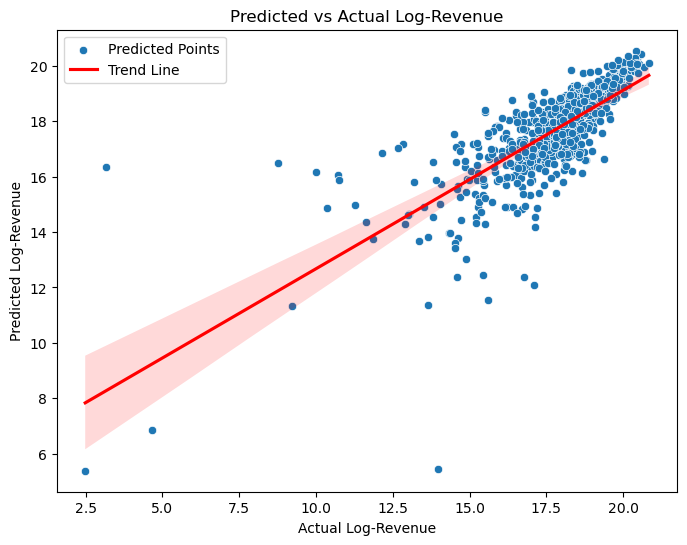

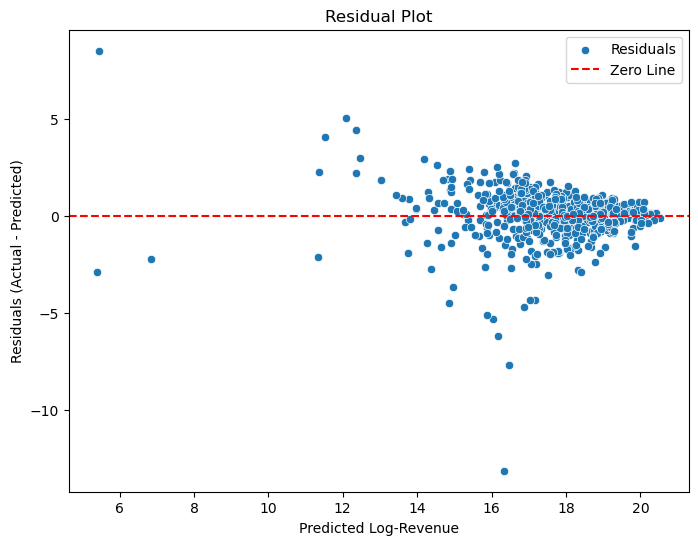

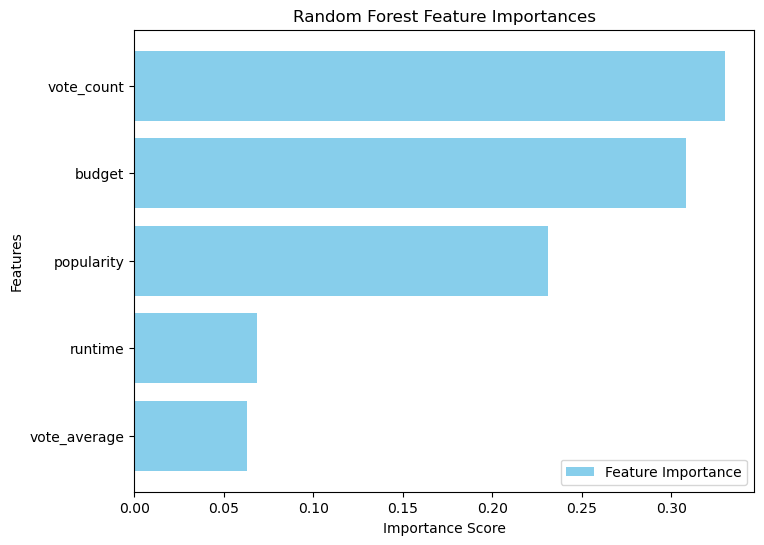

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

csv_path = Path("data/newdata.csv")
df = pd.read_csv(csv_path)

features = ["budget", "runtime", "popularity", "vote_average", "vote_count"]
target = "revenue"

df = df.dropna(subset=features + [target])

X = df[features]
y = np.log1p(df[target])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Configure and train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, label="Predicted Points")
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red', label='Trend Line')
plt.xlabel("Actual Log-Revenue")
plt.ylabel("Predicted Log-Revenue")
plt.title("Predicted vs Actual Log-Revenue")
plt.legend()
plt.show()

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, label="Residuals")
plt.axhline(0, color='red', linestyle='--', label="Zero Line")
plt.xlabel("Predicted Log-Revenue")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.legend()
plt.show()

# Feature Importance Plot
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importances)), importances[indices], color='skyblue', label="Feature Importance")
plt.yticks(range(len(importances)), [features[i] for i in indices])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importances")
plt.legend()
plt.show()

b.(20%) Interactive Plotly/Dash Visualization

Based on your tasks, create at least one interactive dashboard or figure using plotly.express or Dash. For example, interactive scatter plot of predicted vs actual values with hover tooltips; ROC curve with hover threshold values; Dashboard with tabs or dropdowns to view different models, metrics, or feature importances. |

Include necessary screenshots in your r to show it is interactiveeport.

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

csv_path = Path("data/newdata.csv")
df = pd.read_csv(csv_path)

features = ["budget", "runtime", "popularity", "vote_average", "vote_count"]
target = "revenue"

df = df.dropna(subset=features + [target])

X = df[features]
y = np.log1p(df[target])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Configure and train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    "Actual Log-Revenue": y_test,
    "Predicted Log-Revenue": y_pred,
    "Absolute Error": np.abs(y_test - y_pred),
})

# Create interactive scatter plot
fig = px.scatter(
    plot_df,
    x="Actual Log-Revenue",
    y="Predicted Log-Revenue",
    color="Absolute Error",
    title="Interactive Predicted vs Actual Log-Revenue",
    labels={
        "Actual Log-Revenue": "Actual Log-Revenue",
        "Predicted Log-Revenue": "Predicted Log-Revenue",
        "Absolute Error": "Absolute Error"
    },
    hover_data=["Absolute Error"],
    color_continuous_scale="Portland"
)

# Add y=x reference line
fig.add_shape(
    type="line",
    x0=plot_df["Actual Log-Revenue"].min(),
    y0=plot_df["Actual Log-Revenue"].min(),
    x1=plot_df["Actual Log-Revenue"].max(),
    y1=plot_df["Actual Log-Revenue"].max(),
    line=dict(color="red", width=2, dash="dash"),
)

fig.show()


Task 1 — Model Validation
Cross-Validation Results

Using 5-fold cross validation on our Random Forest Regressor, we obtained:

R²: 0.611 ± 0.032

RMSE: 1 ± 0

These results show that the model is stable across folds. The low variance indicates good generalization and no major overfitting. The model performed similarly to Stage III, so cross-validation confirms that the Random Forest is consistent and reliable. Overall, we are satisfied with the performance.

Task 2 — Visualization
Model Visualizations

We created the required regression plots:

Predicted vs Actual Log-Revenue with a fitted trend line

Residual Plot showing errors centered around zero

Feature Importance Plot from the Random Forest

These figures help show how well the model fits the data and which features matter the most.

Interactive Visualization (Plotly)

We built an interactive Plotly scatter plot comparing:

Actual Log-Revenue

Predicted Log-Revenue

Absolute error (color scale)

The hover tooltips allow users to inspect individual prediction errors. A y=x reference line was added for comparison.

Stage IV Summary

In Stage IV, we validated our best model using cross-validation and confirmed that its performance is stable with low variance. We created model-specific visualizations and an interactive Plotly graph to help interpret the results. This stage finalizes our analysis and prepares the visual material needed for our presentation.